In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
# Create generator object
rng = np.random.default_rng(seed=1)
# Generate some test samples
rng.normal(0.8,0.01,10)

array([0.80345584, 0.80821618, 0.80330437, 0.78696843, 0.80905356,
       0.80446375, 0.79463047, 0.80581118, 0.80364572, 0.80294132])

<AxesSubplot:xlabel='Model', ylabel='AUC'>

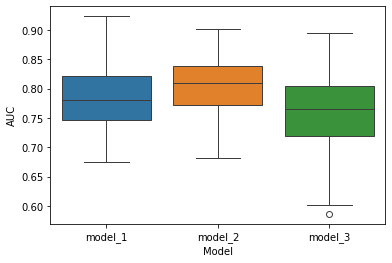

In [3]:
# Logit transformed synthetic data generation

# Standard deviations for the parent and nested intercepts for repeated k fold
parent_sd = 0.1
nested_sd = 0.3
# Standard deviation for performance of all models
sd = 0.2
model_perf = {'model_1':0.8,
              'model_2':0.82,
              'model_3':0.78}
# K fold setup
repeat_count = 15
repeats = range(repeat_count)
folds = range(5)
# List to hold df results
df_list = []
# Loop over the repeats
for repeat in repeats:
    # Sample an intercept for this repeat
    repeat_intercept = rng.normal(0,parent_sd,1)
    #print(repeat,repeat_intercept)
    # Loop over the folds
    for fold in folds:
        # Sample a nested intercept
        repeat_fold_intercept = rng.normal(0,nested_sd,1)
        #print('\t',fold,repeat_fold_intercept)
        # Dataframe for recording this fold's results
        iter_df = pd.DataFrame({'id':fold,'id2':repeat},index=[0])
        # Sample model performance
        for model in sorted(model_perf):
            mean_val = repeat_intercept + repeat_fold_intercept + np.log(model_perf[model]/(1-model_perf[model]))
            sample = 1/(1+np.exp(-1*rng.normal(mean_val,sd)))
            #print('\t\t',model,sample)
            iter_df[model]=sample
        df_list.append(iter_df)
# Concatenate results into a single dataframe
export_df = pd.concat(df_list,ignore_index=True)
# Reformat for a plot
plotting_df = export_df.melt(id_vars=['id','id2'],value_vars=['model_1','model_2','model_3'],value_name='AUC',var_name='Model')

# Take a look at the synthetic data
fig,ax= plt.subplots()
sns.boxplot(plotting_df,x='Model',y='AUC',hue='Model',ax=ax)

In [4]:
export_df.head()

,id,id2,model_1,model_2,model_3
0,0,0,0.803112,0.838975,0.791848
1,1,0,0.828742,0.837583,0.784448
2,2,0,0.788116,0.800099,0.810024
3,3,0,0.759314,0.808981,0.822820
4,4,0,0.786710,0.807834,0.827130


In [5]:
export_df.to_csv('synthetic_performance_dataframe.csv',index=False)